# Linear regression tutorial

In this tutorial, we solve a *regression* problem with the most basic linear model, first by gradient descent and then with the analytical solution from the lecture.

We have a training set of $N$ inputs with one feature each, $x_n \in \mathbb{R}$, and one label each, $y_n \in \mathbb{R}$, for $n = 1, \dots, N$.
The goal is to find a function $f: \mathbb{R} \to \mathbb{R}$ that fits the data well.
We use a linear model with two learnable parameters, the slope $w \in \mathbb{R}$ (the *weight*) and the intercept $b \in \mathbb{R}$ (the *bias*):

$$\hat{y} = f(x, w, b) = w x + b.$$

As in the lecture, we group both into a parameter vector $\boldsymbol{\theta} = (w, b)^\top \in \mathbb{R}^2$, and write $f(x, \boldsymbol{\theta})$ when we want to stress that the model is a function of its parameters.

As objective, we use the mean squared error (MSE) between the labels and the predictions $\hat{y}_n = w x_n + b$:

$$J(w, b) = \frac{1}{N} \sum_{n=1}^N (\hat{y}_n - y_n)^2.$$

We collect the inputs in a data matrix $\mathbf{X} \in \mathbb{R}^{N \times D}$ and the labels in $\mathbf{Y} \in \mathbb{R}^{N \times K}$, one row per example.
Here we simply have $D = 1$ feature and $K = 1$ output.


In [1]:
import matplotlib.pyplot as plt
import numpy as np


# Set Matplotlib backend to `inline` to display the figure below the cell that produced it
%matplotlib inline

In [2]:
def linear_model(X, w, b):
    """Evaluate the linear model with slope w and intercept b.

    Args:
        X: Data matrix of shape (N, D).
        w: Slope (a scalar).
        b: Intercept (a scalar).

    Returns:
        The predictions, of shape (N, K).
    """
    return w * X + b

## 1. Dataset creation

Let's draw some samples for training and test.
The labels come from the line $y = 2x + 3$ plus a little Gaussian noise, which models imperfect observations.

In [3]:
# Sizes (see the notation of lecture 1)
D = 1  # input features per example
K = 1  # outputs per example
N_train = 100  # training examples
N_test = 25  # test examples

rng = np.random.default_rng(42)


def get_label(X, sigma=0.5):
    """Return the noisy labels of the data matrix X (true relationship y = 2x + 3)."""
    noise = sigma * rng.standard_normal(X.shape)
    return 2 * X + 3 + noise


def get_dataset(N):
    """Create a dataset with N examples.

    Returns:
        The data matrix of shape (N, D) and the label matrix of shape (N, K).
    """
    X = rng.uniform(low=0.0, high=2 * np.pi, size=(N, D))
    return X, get_label(X)

X_train has shape (100, 1), Y_train has shape (100, 1)
X_test has shape (25, 1), Y_test has shape (25, 1)


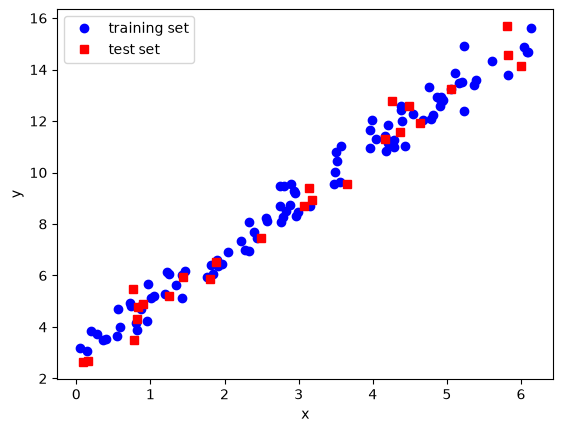

In [4]:
# Draw the training and test set
X_train, Y_train = get_dataset(N_train)
X_test, Y_test = get_dataset(N_test)

print(f"X_train has shape {X_train.shape}, Y_train has shape {Y_train.shape}")
print(f"X_test has shape {X_test.shape}, Y_test has shape {Y_test.shape}")

# Plot the training and test samples
plt.plot(X_train, Y_train, "o", color="blue", label="training set")
plt.plot(X_test, Y_test, "s", color="red", label="test set")
plt.xlabel("x")
plt.ylabel("y")
plt.legend();  # `;` suppresses printing of the return value

**Remark**:
As you can see, we sample data from a linear function (with a little Gaussian noise added).
In a real machine learning problem, however, we have **no access** to the **data generation** process.
For example, in an object classification problem, we don't know the complex function that maps the pixels of an image to some output classes.

In this toy example, we assume we know the data generation function because, this way, we can easily **sample** examples from it.
In any case, the machine learning algorithm only sees the training samples drawn from this model and does not have access to the data generation function itself.

## 2. Training with gradient descent

To perform gradient descent, we need the gradient of the objective (see lecture 2):

$$\frac{\partial J}{\partial w} = \frac{2}{N} \sum_{n=1}^N (\hat{y}_n - y_n)\, x_n, \qquad
\frac{\partial J}{\partial b} = \frac{2}{N} \sum_{n=1}^N (\hat{y}_n - y_n).$$

We keep the factor $2$, so that the code below computes exactly this gradient.
(Some textbooks instead put a $\frac{1}{2}$ into the objective to cancel it; `torch.nn.MSELoss` does not.)

One update of both parameters goes into a function, so that the training loop below only has to call it once per epoch.


In [5]:
def mse(Y, Y_hat):
    """Return the mean squared error between labels and predictions.

    Args:
        Y: Label matrix of shape (N, K).
        Y_hat: Prediction matrix of shape (N, K).

    Returns:
        The mean squared error (a scalar).
    """
    return ((Y_hat - Y) ** 2).mean()


def gd_step(X, Y, w, b, lr):
    """Perform one gradient descent step on the mean squared error.

    Args:
        X: Data matrix of the training set, of shape (N, D).
        Y: Label matrix of the training set, of shape (N, K).
        w: Current slope (a scalar).
        b: Current intercept (a scalar).
        lr: Learning rate (a scalar).

    Returns:
        The updated slope and intercept, both scalars.
    """
    Y_hat = linear_model(X, w, b)
    grad_w = 2 * ((Y_hat - Y) * X).mean()
    grad_b = 2 * (Y_hat - Y).mean()
    return w - lr * grad_w, b - lr * grad_b

In [6]:
# Initial values
w, b = 1.0, 0.5

# Hyperparameters
N_epochs = 1000
lr = 0.025

# Report the progress every `print_every` epochs
print_every = 100

train_loss = []
test_loss = []
for epoch in range(N_epochs):
    # one gradient descent update
    w, b = gd_step(X_train, Y_train, w, b, lr)

    # compute the training and test loss (just to monitor)
    train_loss.append(mse(Y_train, linear_model(X_train, w, b)))
    test_loss.append(mse(Y_test, linear_model(X_test, w, b)))

    if epoch % print_every == 0:
        print(f"epoch {epoch:4d}: train loss = {train_loss[-1]:.4f}, test loss = {test_loss[-1]:.4f}")

print(f"w = {w:.4f}, b = {b:.4f}")

epoch    0: train loss = 5.2025, test loss = 4.7848
epoch  100: train loss = 0.3461, test loss = 0.3532
epoch  200: train loss = 0.2509, test loss = 0.3196
epoch  300: train loss = 0.2409, test loss = 0.3352
epoch  400: train loss = 0.2398, test loss = 0.3431
epoch  500: train loss = 0.2397, test loss = 0.3459
epoch  600: train loss = 0.2397, test loss = 0.3469
epoch  700: train loss = 0.2397, test loss = 0.3472
epoch  800: train loss = 0.2397, test loss = 0.3473
epoch  900: train loss = 0.2397, test loss = 0.3473
w = 2.0061, b = 2.9743


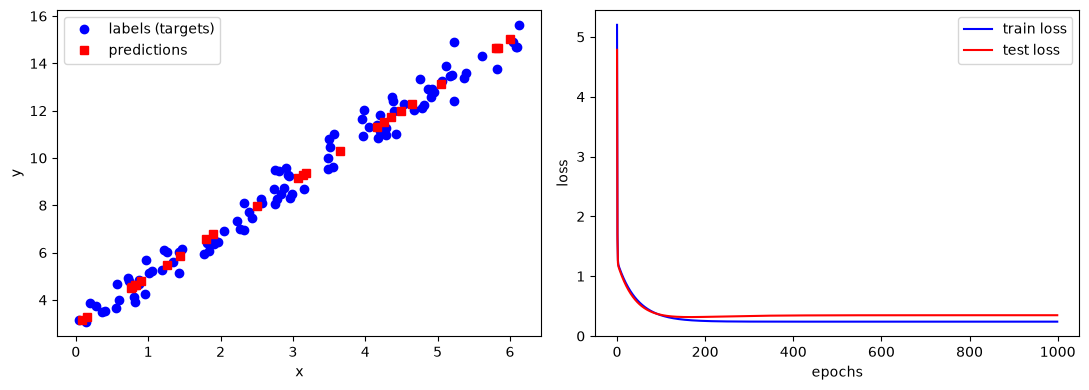

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: the predictions on the test set, next to the training labels
axes[0].plot(X_train, Y_train, "o", color="blue", label="labels (targets)")
axes[0].plot(X_test, linear_model(X_test, w, b), "s", color="red", label="predictions")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

# Right: the training curves
axes[1].plot(train_loss, color="blue", label="train loss")
axes[1].plot(test_loss, color="red", label="test loss")
axes[1].set_xlabel("epochs")
axes[1].set_ylabel("loss")
axes[1].legend()

fig.tight_layout()

## 3. Analytical solution

For linear regression, the minimizer of the objective has a closed form (see lecture 3).
It works with a single parameter vector, so we append a $1$ to every input.
The bias then becomes the last entry of that vector and is treated like any other weight.
We call the result the *bias-augmented data matrix* $\tilde{\mathbf{X}} \in \mathbb{R}^{N \times (D + 1)}$:

$$\boldsymbol{\theta} = \begin{pmatrix} w \\ b \end{pmatrix}, \qquad
\tilde{\mathbf{X}} = \begin{pmatrix} x_1 & 1 \\ x_2 & 1 \\ \vdots & \vdots \\ x_N & 1 \end{pmatrix}, \qquad
\mathbf{Y} = \begin{pmatrix} y_1 \\ y_2 \\ \vdots \\ y_N \end{pmatrix}.$$

With these, the optimal parameters are

$$\boldsymbol{\theta}^* = (\tilde{\mathbf{X}}^\top \tilde{\mathbf{X}})^{-1} \tilde{\mathbf{X}}^\top \mathbf{Y}.$$


In [8]:
# The bias-augmented data matrix, of shape (N_train, D + 1)
X_tilde = np.concatenate([X_train, np.ones_like(X_train)], axis=1)

# `squeeze` drops the output axis (K = 1), leaving a parameter vector of shape (D + 1,)
theta_star = (np.linalg.inv(X_tilde.T @ X_tilde) @ X_tilde.T @ Y_train).squeeze(axis=1)

print(f"w = {theta_star[0]:.4f}, b = {theta_star[1]:.4f}")

# Gradient descent stops near the minimizer, not exactly on it, so we allow a relative tolerance
assert np.allclose([w, b], theta_star, rtol=1e-4), "Gradient descent did not reach the analytical solution!"

w = 2.0061, b = 2.9743


The solution matches the one found by gradient descent, up to the small error that stops the iteration short of the exact minimizer.
Unfortunately, such a closed-form solution exists only for few models: logistic regression, for instance, already has none (see lecture 3).

We can also compute the analytical solution with scikit-learn:


In [9]:
from sklearn.linear_model import LinearRegression

# scikit-learn takes the data matrix without the column of ones and adds the intercept itself
regressor = LinearRegression().fit(X_train, Y_train)
w_sklearn, b_sklearn = regressor.coef_[0, 0], regressor.intercept_[0]
print(f"w = {w_sklearn:.4f}, b = {b_sklearn:.4f}")

# This solves the same equations as above, so the agreement is down to floating point
assert np.allclose([w_sklearn, b_sklearn], theta_star, rtol=1e-10), "scikit-learn disagrees with the analytical solution!"

w = 2.0061, b = 2.9743


Same solution again, this time to the last digit, because scikit-learn solves the very same equations.

## Conclusion

We have seen three ways to perform linear regression: gradient descent, the analytical solution, and scikit-learn, which computes the analytical solution for us.
The `assert` statements above are our check that all three agree.
